# DATA1010 Final Project — Task 2: Supervised Learning

**Goal:** Predict whether Hanoi air quality reaches a warning level (is_warning) using supervised classification models.

This notebook builds a full supervised-learning workflow for the air-quality warning prediction task. The main modelling approach uses weather and time variables only, so the required models are compared fairly using the same input feature set. AQI is excluded because it is closely tied to how the warning label is created and would therefore cause data leakage.

The notebook includes:

Initial data loading and quality checks.
Timestamp conversion and season creation for split/evaluation purposes.
A season-aware chronological train/test split.
Baseline, Logistic Regression, SVM, tuned SVM, and Random Forest models.
Model comparison tables, rankings, improvement over baseline, and visual comparisons.
Best-model visualisation using confusion matrix, ROC curve, and Precision-Recall curve.
Feature interpretation for Logistic Regression and Random Forest.
A separate PM2.5 sensor-assisted Logistic Regression experiment.
A report-ready summary paragraph.

The PM2.5 model is intentionally treated as an extra experiment, not part of the regular model ranking, because it uses additional pollution-sensor information rather than only weather and time features.

## 1. Import libraries

This section imports the Python packages required for the full supervised-learning workflow. pandas and numpy are used for data handling, matplotlib is used for visualisations, and scikit-learn provides preprocessing tools, classifiers, model-selection methods, and evaluation metrics. A fixed RANDOM_STATE is used where possible so that model training and tuning results are reproducible.

In [85]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay, classification_report
)

RANDOM_STATE = 42

## 2. Load the dataset

In Google Colab, upload `hanoi_air_quality(2).csv` when the upload button appears.

This section loads the Hanoi air-quality dataset directly from Google Drive. After loading, the code prints the dataset shape and displays the first few rows so that the file has been imported correctly and the main columns are visible before modelling begins.

In [86]:
file_id = "1201kH-R9xdCT2nh36fPVgNZJENsjlcBW"
url = f"https://drive.google.com/uc?export=download&id={file_id}"

df = pd.read_csv(url)
print("\n Dataset loaded from Google Drive.")

print("Shape:", df.shape)
df.head()


 Dataset loaded from Google Drive.
Shape: (8760, 14)


,timestamp,temperature,humidity,wind_speed,pressure,hour,day_of_week,is_weekend,wind_direction,precipitation,cloud_cover,is_warning,aqi,pm25
0,2025-01-01 00:00:00,14.1,91,1.138889,1016.6,0,2,0,319,0.0,0,1,158,111.3
1,2025-01-01 01:00:00,13.5,93,1.277778,1016.6,1,2,0,321,0.0,4,1,159,112.7
2,2025-01-01 02:00:00,12.9,94,1.083333,1016.1,2,2,0,317,0.0,0,1,160,113.2
3,2025-01-01 03:00:00,12.6,96,1.277778,1015.5,3,2,0,315,0.0,0,1,162,113.9
4,2025-01-01 04:00:00,12.4,96,1.277778,1015.4,4,2,0,312,0.0,2,1,163,115.5


## 3. Basic data check

Before building any models, this section checks the structure and quality of the dataset. It lists all column names, counts missing values, shows the target-class distribution, and displays summary statistics. This is important because classification performance can be strongly affected by missing values, class imbalance, and unexpected feature ranges.

In [87]:
print("Columns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum())

print("\nTarget distribution:")
print(df["is_warning"].value_counts())
print(df["is_warning"].value_counts(normalize=True).round(3))

df.describe().T

Columns:
['timestamp', 'temperature', 'humidity', 'wind_speed', 'pressure', 'hour', 'day_of_week', 'is_weekend', 'wind_direction', 'precipitation', 'cloud_cover', 'is_warning', 'aqi', 'pm25']

Missing values:
timestamp         0
temperature       0
humidity          0
wind_speed        0
pressure          0
hour              0
day_of_week       0
is_weekend        0
wind_direction    0
precipitation     0
cloud_cover       0
is_warning        0
aqi               0
pm25              0
dtype: int64

Target distribution:
is_warning
1    6709
0    2051
Name: count, dtype: int64
is_warning
1    0.766
0    0.234
Name: proportion, dtype: float64


,count,mean,std,min,25%,50%,75%,max
temperature,8760.0,23.891598,5.380846,7.3,20.000000,24.700000,27.700000,37.800000
humidity,8760.0,79.402511,14.865277,26.0,70.000000,82.000000,92.000000,100.000000
wind_speed,8760.0,2.405533,1.299560,0.0,1.416667,2.277778,3.222222,9.555556
pressure,8760.0,1009.156427,7.529136,986.5,1003.200000,1008.800000,1015.200000,1032.100000
hour,8760.0,11.500000,6.922582,0.0,5.750000,11.500000,17.250000,23.000000
day_of_week,8760.0,2.997260,1.998056,0.0,1.000000,3.000000,5.000000,6.000000
is_weekend,8760.0,0.284932,0.451408,0.0,0.000000,0.000000,1.000000,1.000000
wind_direction,8760.0,142.330822,99.267179,1.0,63.000000,134.500000,169.000000,360.000000
precipitation,8760.0,0.273482,1.135449,0.0,0.000000,0.000000,0.100000,28.800000
cloud_cover,8760.0,74.632078,37.528658,0.0,46.000000,100.000000,100.000000,100.000000


## 4. Define target and avoid data leakage

The target variable is is_warning, where 1 represents a warning-level air-quality observation and 0 represents a non-warning observation.

A key modelling decision is to exclude aqi from the input features. Since the warning label is normally derived from AQI or a very similar threshold, including AQI would allow the model to almost directly recover the answer. This would create data leakage and make the results unrealistically strong.

The regular models therefore use only weather and time features:

temperature
humidity
wind_speed
pressure
hour
day_of_week

The code also creates month and season from the timestamp. Season is used only to construct a fairer train/test split and to evaluate seasonal performance. It is not included as a model input feature.

In [88]:
# Convert timestamp for sorting and optional feature engineering
if "timestamp" in df.columns:
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values("timestamp").reset_index(drop=True)

# Create season column for splitting/evaluation only
# Season is NOT used as an input feature.
def month_to_season(month):
    if month in [1, 2, 3]:
        return "Spring"
    elif month in [4, 5, 6]:
        return "Summer"
    elif month in [7, 8, 9]:
        return "Autumn"
    else:
        return "Winter"

if "timestamp" in df.columns:
    df["month"] = df["timestamp"].dt.month
    df["season"] = df["month"].apply(month_to_season)

# Anti-leakage check: is_warning is usually defined by AQI > 100
if "aqi" in df.columns:
    match_rate = (df["is_warning"] == (df["aqi"] > 100).astype(int)).mean()
    print(f"Match rate between is_warning and (aqi > 100): {match_rate:.3f}")
    print("Because this value is very high, AQI should not be used as an input feature.")

main_features = [
    "temperature",
    "humidity",
    "wind_speed",
    "pressure",
    "hour",
    "day_of_week"
]

target = "is_warning"

print("Main model features:", main_features)
print("Target variable:", target)
print("The season column is used only for splitting/evaluation, not as a model feature.")

Match rate between is_warning and (aqi > 100): 1.000
Because this value is very high, AQI should not be used as an input feature.
Main model features: ['temperature', 'humidity', 'wind_speed', 'pressure', 'hour', 'day_of_week']
Target variable: is_warning
The season column is used only for splitting/evaluation, not as a model feature.


## 5. Train/test split

Because the dataset is hourly time-series data over one year, a purely random split could mix earlier and later observations in an unrealistic way. It could also create seasonal imbalance if some seasons are over-represented in either training or testing.

To reduce this problem, the notebook uses a season-aware chronological 70/30 split. The data is first separated into Spring, Summer, Autumn, and Winter. Within each season, the earlier 70% of observations is used for training and the later 30% is used for testing. The seasonal training parts are then combined into one final training set, and the seasonal testing parts are combined into one final testing set.

This approach keeps the test set later in time within each season while still making sure every season appears in both training and testing observations that it has not seen before.

In [89]:
def seasonal_chronological_split(df, features, target="is_warning", train_size=0.7):
    train_parts = []
    test_parts = []

    season_order = ["Spring", "Summer", "Autumn", "Winter"]

    for season in season_order:
        season_df = df[df["season"] == season].sort_values("timestamp").copy()

        split_index = int(len(season_df) * train_size)

        train_part = season_df.iloc[:split_index]
        test_part = season_df.iloc[split_index:]

        train_parts.append(train_part)
        test_parts.append(test_part)

    train_df = pd.concat(train_parts).sort_values("timestamp").reset_index(drop=True)
    test_df = pd.concat(test_parts).sort_values("timestamp").reset_index(drop=True)

    X_train = train_df[features].copy()
    y_train = train_df[target].copy()

    X_test = test_df[features].copy()
    y_test = test_df[target].copy()

    return X_train, X_test, y_train, y_test, train_df, test_df


DEFAULT_TRAIN_SIZE = 0.7

X_train, X_test, y_train, y_test, train_df, test_df = seasonal_chronological_split(
    df,
    main_features,
    target,
    train_size=DEFAULT_TRAIN_SIZE
)

print("Season-aware chronological split")
print("Train ratio inside each season:", DEFAULT_TRAIN_SIZE)
print("Test ratio inside each season:", round(1 - DEFAULT_TRAIN_SIZE, 2))
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Train target rate:", y_train.mean().round(3))
print("Test target rate:", y_test.mean().round(3))

print("\nSeason distribution in train set:")
display(train_df["season"].value_counts().loc[["Spring", "Summer", "Autumn", "Winter"]])

print("\nSeason distribution in test set:")
display(test_df["season"].value_counts().loc[["Spring", "Summer", "Autumn", "Winter"]])

print("\nWarning rate by season in train set:")
display(train_df.groupby("season")[target].mean().loc[["Spring", "Summer", "Autumn", "Winter"]].round(3))

print("\nWarning rate by season in test set:")
display(test_df.groupby("season")[target].mean().loc[["Spring", "Summer", "Autumn", "Winter"]].round(3))

Season-aware chronological split
Train ratio inside each season: 0.7
Test ratio inside each season: 0.3
Training samples: 6130
Testing samples: 2630
Train target rate: 0.752
Test target rate: 0.799

Season distribution in train set:


,count
season,
Spring,1512
Summer,1528
Autumn,1545
Winter,1545



Season distribution in test set:


,count
season,
Spring,648
Summer,656
Autumn,663
Winter,663



Warning rate by season in train set:


,is_warning
season,
Spring,0.707
Summer,0.885
Autumn,0.846
Winter,0.570



Warning rate by season in test set:


,is_warning
season,
Spring,0.699
Summer,0.913
Autumn,0.753
Winter,0.830


## 6. Evaluation helper functions

This section defines reusable functions for model evaluation and visualisation. The same functions are used across all models so that the comparison is consistent. The metrics include accuracy, precision, recall, F1-score, and ROC-AUC. F1-score is especially important because the target classes may be imbalanced and the task cares about identifying warning cases, not only overall accuracy.

In [90]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    rows = []

    for split_name, X_part, y_part in [
        ("Train", X_train, y_train),
        ("Test", X_test, y_test)
    ]:
        y_pred = model.predict(X_part)

        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_part)[:, 1]
        else:
            y_score = model.decision_function(X_part)

        try:
            roc_auc = roc_auc_score(y_part, y_score)
        except ValueError:
            roc_auc = np.nan

        rows.append({
            "Model": model_name,
            "Split": split_name,
            "Accuracy": accuracy_score(y_part, y_pred),
            "Precision": precision_score(y_part, y_pred, zero_division=0),
            "Recall": recall_score(y_part, y_pred, zero_division=0),
            "F1-score": f1_score(y_part, y_pred, zero_division=0),
            "Balanced Accuracy": balanced_accuracy_score(y_part, y_pred),
            "Macro F1": f1_score(y_part, y_pred, average="macro", zero_division=0),
            "ROC-AUC": roc_auc
        })

    return pd.DataFrame(rows)


def show_confusion_matrix(model, X_test, y_test, title):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No warning", "Warning"]
    )

    disp.plot(values_format="d")
    plt.title(title)
    plt.show()


def plot_roc_and_pr(model, X_test, y_test, title):
    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title(f"ROC Curve - {title}")
    plt.show()

    PrecisionRecallDisplay.from_estimator(model, X_test, y_test)
    plt.title(f"Precision-Recall Curve - {title}")
    plt.show()

## 7. Baseline model

A baseline model is needed to judge whether the machine-learning models are genuinely useful. Here, the baseline always predicts the most frequent class in the training data. If the real models cannot clearly outperform this simple rule, then their apparent performance would not be meaningful. The baseline is especially important when the target variable is imbalanced.

In [91]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

baseline_results = evaluate_model(
    baseline, X_train, y_train, X_test, y_test,
    "Baseline: always predict majority class"
)
baseline_results

,Model,Split,Accuracy,Precision,Recall,F1-score,Balanced Accuracy,Macro F1,ROC-AUC
0,Baseline: always predict majority class,Train,0.751713,0.751713,1.0,0.858260,0.5,0.429130,0.5
1,Baseline: always predict majority class,Test,0.798859,0.798859,1.0,0.888184,0.5,0.444092,0.5


## 8. Required model 1: Logistic Regression

Logistic Regression is used as an interpretable linear classification model. We use `StandardScaler` because the features have different units, such as pressure, wind speed, and precipitation.

In [92]:
def make_logistic_model():
    return Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ])


# Train one global Logistic Regression model using the season-aware split
logistic_model = make_logistic_model()
logistic_model.fit(X_train, y_train)

logistic_results = evaluate_model(
    logistic_model,
    X_train,
    y_train,
    X_test,
    y_test,
    "Logistic Regression"
)

print("Final Logistic Regression performance using season-aware chronological split:")
display(logistic_results.round(3))

Final Logistic Regression performance using season-aware chronological split:


,Model,Split,Accuracy,Precision,Recall,F1-score,Balanced Accuracy,Macro F1,ROC-AUC
0,Logistic Regression,Train,0.654,0.845,0.661,0.742,0.647,0.609,0.717
1,Logistic Regression,Test,0.678,0.882,0.689,0.774,0.662,0.608,0.721


## 9. Required model 2: Support Vector Machine baseline

SVM is useful because it can build a decision boundary between warning and non-warning cases. We first try a simple RBF SVM, then tune it more carefully.

In [93]:
svm_basic = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", SVC(
        kernel="rbf",
        C=1,
        gamma="scale",
        class_weight="balanced",
        probability=True,
        random_state=RANDOM_STATE
    ))
])

svm_basic.fit(X_train, y_train)

svm_basic_results = evaluate_model(
    svm_basic, X_train, y_train, X_test, y_test,
    "SVM RBF basic"
)
svm_basic_results

,Model,Split,Accuracy,Precision,Recall,F1-score,Balanced Accuracy,Macro F1,ROC-AUC
0,SVM RBF basic,Train,0.786297,0.903573,0.801215,0.849321,0.771173,0.740981,0.850674
1,SVM RBF basic,Test,0.711407,0.853903,0.770585,0.810108,0.623478,0.604579,0.699131


## 10. Excellent-level improvement: tune SVM hyperparameters

We tune:
- `kernel`: linear or RBF
- `C`: how strongly the model penalizes mistakes
- `gamma`: how flexible the RBF boundary is

The tuning target is F1-score because the target is imbalanced and we care about detecting warning cases, not only overall accuracy.

In [94]:
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

svm_grid = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", SVC(
        class_weight="balanced",
        probability=False,
        random_state=RANDOM_STATE
    ))
])

param_grid = [
    {
        "model__kernel": ["linear"],
        "model__C": [0.1, 1, 10]
    },
    {
        "model__kernel": ["rbf"],
        "model__C": [0.1, 1, 10],
        "model__gamma": ["scale", 0.01]
    }
]

grid_search = GridSearchCV(
    estimator=svm_grid,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=1,
    return_train_score=True,
    verbose=0
)

grid_search.fit(X_train, y_train)

print("Best SVM parameters:", grid_search.best_params_)
print("Best cross-validation F1-score:", round(grid_search.best_score_, 4))

best_svm = grid_search.best_estimator_

tuned_svm_results = evaluate_model(
    best_svm, X_train, y_train, X_test, y_test,
    "Tuned SVM"
)

tuned_svm_results

Best SVM parameters: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Best cross-validation F1-score: 0.8587


,Model,Split,Accuracy,Precision,Recall,F1-score,Balanced Accuracy,Macro F1,ROC-AUC
0,Tuned SVM,Train,0.834910,0.940902,0.832682,0.883491,0.837169,0.800167,0.906535
1,Tuned SVM,Test,0.713308,0.838953,0.793432,0.815558,0.594258,0.586107,0.664841


## 11. Optional extra model: Random Forest

This is not required, but it strengthens the project because the rubric rewards extra exploration and optimization. Random Forest can capture non-linear patterns without requiring scaling.

In [95]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

rf_model.fit(X_train, y_train)

rf_results = evaluate_model(
    rf_model, X_train, y_train, X_test, y_test,
    "Extra: Random Forest"
)
rf_results

,Model,Split,Accuracy,Precision,Recall,F1-score,Balanced Accuracy,Macro F1,ROC-AUC
0,Extra: Random Forest,Train,0.987113,0.995623,0.987196,0.991392,0.987028,0.982884,0.999301
1,Extra: Random Forest,Test,0.800760,0.839140,0.928605,0.881609,0.610806,0.626656,0.723187


## 12. Compare all models

This section compares the regular models using the same weather and time input features. The PM2.5-assisted model is not included in this main ranking because it uses an additional pollution-sensor variable and would not be a fair direct comparison.

The comparison focuses on test-set results, especially F1-score and ROC-AUC. F1-score is used as the main ranking metric because warning detection depends on balancing false positives and false negatives.

In [96]:
all_results = pd.concat([
    baseline_results,
    logistic_results,
    svm_basic_results,
    tuned_svm_results,
    rf_results
], ignore_index=True)

all_results_rounded = all_results.copy()
metric_cols = [
    "Accuracy", "Precision", "Recall", "F1-score",
    "Balanced Accuracy", "Macro F1", "ROC-AUC"
]
all_results_rounded[metric_cols] = all_results_rounded[metric_cols].round(4)
all_results_rounded

,Model,Split,Accuracy,Precision,Recall,F1-score,Balanced Accuracy,Macro F1,ROC-AUC
0,Baseline: always predict majority class,Train,0.7517,0.7517,1.0000,0.8583,0.5000,0.4291,0.5000
1,Baseline: always predict majority class,Test,0.7989,0.7989,1.0000,0.8882,0.5000,0.4441,0.5000
2,Logistic Regression,Train,0.6542,0.8448,0.6615,0.7420,0.6468,0.6089,0.7171
3,Logistic Regression,Test,0.6783,0.8824,0.6892,0.7739,0.6622,0.6083,0.7209
4,SVM RBF basic,Train,0.7863,0.9036,0.8012,0.8493,0.7712,0.7410,0.8507
5,SVM RBF basic,Test,0.7114,0.8539,0.7706,0.8101,0.6235,0.6046,0.6991
6,Tuned SVM,Train,0.8349,0.9409,0.8327,0.8835,0.8372,0.8002,0.9065
7,Tuned SVM,Test,0.7133,0.8390,0.7934,0.8156,0.5943,0.5861,0.6648
8,Extra: Random Forest,Train,0.9871,0.9956,0.9872,0.9914,0.9870,0.9829,0.9993
9,Extra: Random Forest,Test,0.8008,0.8391,0.9286,0.8816,0.6108,0.6267,0.7232


Filter the combined results to the test set only and sort models by F1-score. This gives the main fair comparison among regular models.

In [97]:
# Test-set comparison only
comparison_test = all_results_rounded[all_results_rounded["Split"] == "Test"].sort_values(
    by="F1-score", ascending=False
)
comparison_test

,Model,Split,Accuracy,Precision,Recall,F1-score,Balanced Accuracy,Macro F1,ROC-AUC
1,Baseline: always predict majority class,Test,0.7989,0.7989,1.0000,0.8882,0.5000,0.4441,0.5000
9,Extra: Random Forest,Test,0.8008,0.8391,0.9286,0.8816,0.6108,0.6267,0.7232
7,Tuned SVM,Test,0.7133,0.8390,0.7934,0.8156,0.5943,0.5861,0.6648
5,SVM RBF basic,Test,0.7114,0.8539,0.7706,0.8101,0.6235,0.6046,0.6991
3,Logistic Regression,Test,0.6783,0.8824,0.6892,0.7739,0.6622,0.6083,0.7209


Add explicit F1 and ROC-AUC ranks to the regular test-set comparison table. This makes the model ranking clearer for the report.

In [98]:
regular_model_ranking = comparison_test.copy()
regular_model_ranking = regular_model_ranking[
    regular_model_ranking["Model"] != "Baseline: always predict majority class"
].copy()

regular_model_ranking["F1 Rank"] = regular_model_ranking["F1-score"].rank(
    ascending=False,
    method="dense"
).astype(int)

regular_model_ranking["ROC-AUC Rank"] = regular_model_ranking["ROC-AUC"].rank(
    ascending=False,
    method="dense"
).astype(int)

regular_model_ranking = regular_model_ranking.sort_values(
    by=["F1-score", "ROC-AUC"],
    ascending=False
)

display(regular_model_ranking[
    [
        "F1 Rank", "ROC-AUC Rank", "Model",
        "Accuracy", "Precision", "Recall", "F1-score",
        "Balanced Accuracy", "Macro F1", "ROC-AUC"
    ]
])

,F1 Rank,ROC-AUC Rank,Model,Accuracy,Precision,Recall,F1-score,Balanced Accuracy,Macro F1,ROC-AUC
9,1,1,Extra: Random Forest,0.8008,0.8391,0.9286,0.8816,0.6108,0.6267,0.7232
7,2,4,Tuned SVM,0.7133,0.8390,0.7934,0.8156,0.5943,0.5861,0.6648
5,3,3,SVM RBF basic,0.7114,0.8539,0.7706,0.8101,0.6235,0.6046,0.6991
3,4,2,Logistic Regression,0.6783,0.8824,0.6892,0.7739,0.6622,0.6083,0.7209


## 13. Visualize the best model

After comparing the required models, this section selects the better model between Logistic Regression and basic RBF SVM based on test F1-score. It then visualises that model using a confusion matrix, ROC curve, Precision-Recall curve, and classification report.

These outputs provide more detail than a single metric. The confusion matrix shows the number of correct and incorrect predictions, while the ROC and Precision-Recall curves show how the model behaves across different decision thresholds.

Select the best required model by test F1-score, then show its confusion matrix, ROC curve, Precision-Recall curve, and classification report.

Best required model on test set: SVM RBF basic


,Model,Split,Accuracy,Precision,Recall,F1-score,Balanced Accuracy,Macro F1,ROC-AUC
5,SVM RBF basic,Test,0.711,0.854,0.771,0.810,0.624,0.605,0.699
3,Logistic Regression,Test,0.678,0.882,0.689,0.774,0.662,0.608,0.721


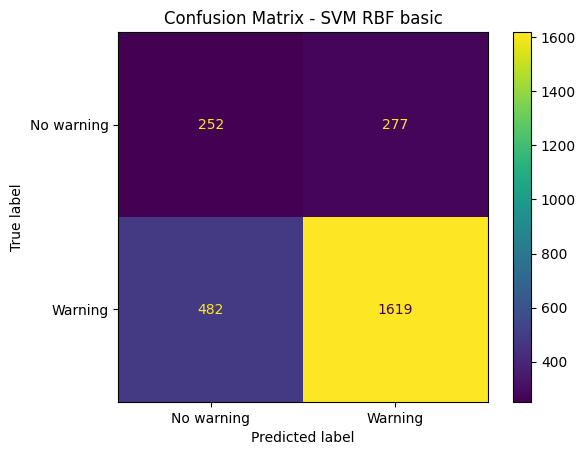

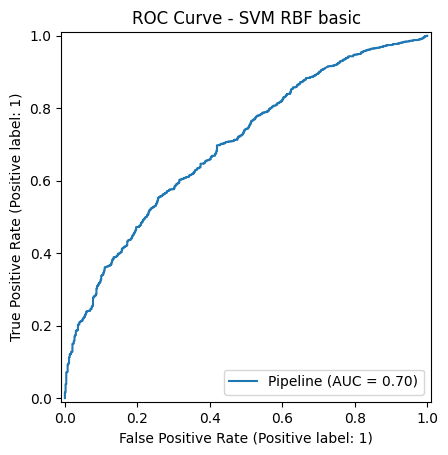

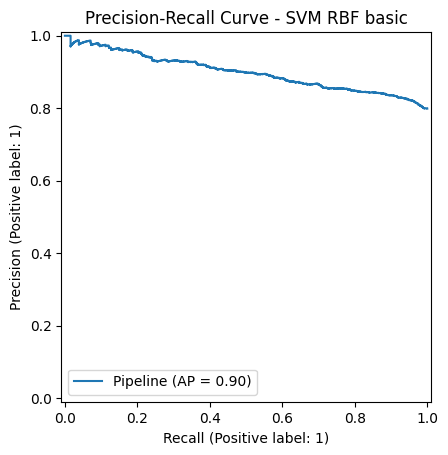

Classification report on test set:
              precision    recall  f1-score   support

  No warning       0.34      0.48      0.40       529
     Warning       0.85      0.77      0.81      2101

    accuracy                           0.71      2630
   macro avg       0.60      0.62      0.60      2630
weighted avg       0.75      0.71      0.73      2630



In [99]:
# Select the best required model only between Logistic Regression and basic RBF SVM
comparison_required = comparison_test[
    comparison_test["Model"].isin(["Logistic Regression", "SVM RBF basic"])
].copy()

# Select the best required model based on highest test F1-score
best_model_name = comparison_required.iloc[0]["Model"]

print("Best required model on test set:", best_model_name)
display(comparison_required.round(3))

model_dict = {
    "Logistic Regression": logistic_model,
    "SVM RBF basic": svm_basic
}

best_model = model_dict[best_model_name]

show_confusion_matrix(
    best_model,
    X_test,
    y_test,
    f"Confusion Matrix - {best_model_name}"
)

plot_roc_and_pr(
    best_model,
    X_test,
    y_test,
    best_model_name
)

print("Classification report on test set:")
print(
    classification_report(
        y_test,
        best_model.predict(X_test),
        target_names=["No warning", "Warning"],
        zero_division=0
    )
)

Create a compact bar chart comparing F1-score and ROC-AUC across the regular models on the test set.

In [100]:
def evaluate_by_season(model, test_df, features, target="is_warning"):
    rows = []

    for season in ["Spring", "Summer", "Autumn", "Winter"]:
        season_test = test_df[test_df["season"] == season].copy()

        X_season = season_test[features]
        y_season = season_test[target]

        y_pred = model.predict(X_season)

        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_season)[:, 1]
        else:
            y_score = model.decision_function(X_season)

        try:
            roc_auc = roc_auc_score(y_season, y_score)
        except ValueError:
            roc_auc = np.nan

        rows.append({
            "Season": season,
            "Samples": len(season_test),
            "Warning Rate": y_season.mean(),
            "Accuracy": accuracy_score(y_season, y_pred),
            "Precision": precision_score(y_season, y_pred, zero_division=0),
            "Recall": recall_score(y_season, y_pred, zero_division=0),
            "F1-score": f1_score(y_season, y_pred, zero_division=0),
            "ROC-AUC": roc_auc
        })

    return pd.DataFrame(rows)


season_results = evaluate_by_season(
    best_model,
    test_df,
    main_features,
    target
)

print("Best model performance by season:")
display(season_results.round(3))

Best model performance by season:


,Season,Samples,Warning Rate,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Spring,648,0.699,0.557,0.753,0.545,0.633,0.630
1,Summer,656,0.913,0.875,0.910,0.958,0.933,0.479
2,Autumn,663,0.753,0.757,0.820,0.868,0.843,0.744
3,Winter,663,0.830,0.655,0.892,0.664,0.761,0.696


## 14. Feature interpretation

This section interprets the features used by the models. For Logistic Regression, positive coefficients mean that higher values of a feature increase the predicted probability of a warning, while negative coefficients reduce it. For Random Forest, feature importance indicates which variables contributed most to the model’s decision-making.

Because Logistic Regression uses scaled features in the pipeline, the coefficients are more comparable across variables than they would be without scaling.

Logistic Regression coefficients:


,Feature,Coefficient
5,day_of_week,0.182162
0,temperature,0.069945
4,hour,-0.094743
1,humidity,-0.197221
2,wind_speed,-0.591990
3,pressure,-0.597225


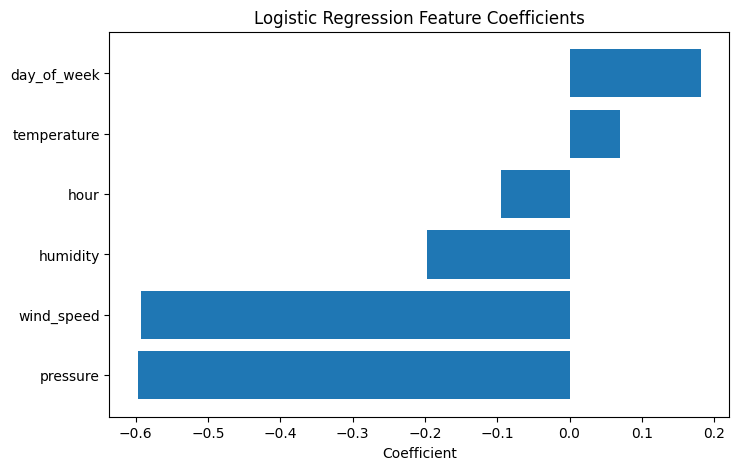

Random Forest feature importance:


,Feature,Importance
3,pressure,0.234230
0,temperature,0.217707
2,wind_speed,0.195597
1,humidity,0.128057
5,day_of_week,0.119959
4,hour,0.104449


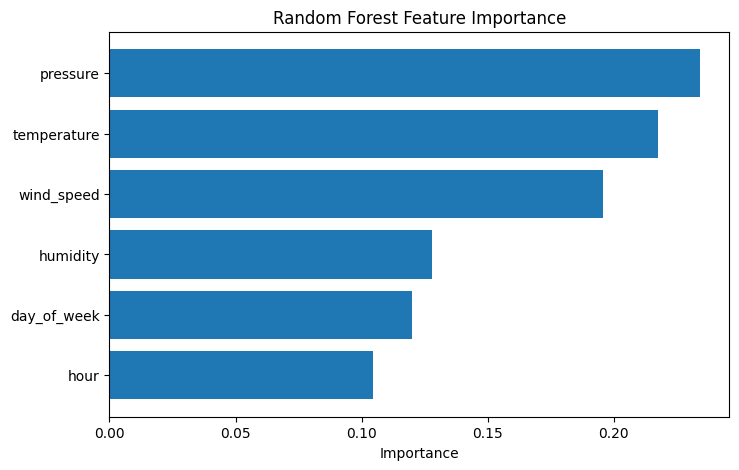

In [101]:
# Logistic Regression coefficients
log_reg = logistic_model.named_steps["model"]
coef_df = pd.DataFrame({
    "Feature": main_features,
    "Coefficient": log_reg.coef_[0]
}).sort_values("Coefficient", ascending=False)

print("Logistic Regression coefficients:")
display(coef_df)

plt.figure(figsize=(8, 5))
plt.barh(coef_df["Feature"], coef_df["Coefficient"])
plt.xlabel("Coefficient")
plt.title("Logistic Regression Feature Coefficients")
plt.gca().invert_yaxis()
plt.show()

# Random Forest feature importance
rf_importance = pd.DataFrame({
    "Feature": main_features,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("Random Forest feature importance:")
display(rf_importance)

plt.figure(figsize=(8, 5))
plt.barh(rf_importance["Feature"], rf_importance["Importance"])
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

## 15. Report-ready conclusion text

Run the code cell below after getting your actual results. Then copy the printed paragraph into the report and adjust the numbers if needed.

In [102]:
# Extract best required model between Logistic Regression and basic RBF SVM only
required_models = all_results_rounded[
    (all_results_rounded["Split"] == "Test") &
    (all_results_rounded["Model"].isin(["Logistic Regression", "SVM RBF basic"]))
].sort_values("F1-score", ascending=False)

best_required = required_models.iloc[0]

log_test = all_results_rounded[
    (all_results_rounded["Model"] == "Logistic Regression") &
    (all_results_rounded["Split"] == "Test")
].iloc[0]

svm_test = all_results_rounded[
    (all_results_rounded["Model"] == "SVM RBF basic") &
    (all_results_rounded["Split"] == "Test")
].iloc[0]

report_text = f"""
For Task 2, we predicted the binary warning status of Hanoi air quality using supervised learning models. The target variable was is_warning, where 1 means warning and 0 means no warning. To avoid data leakage, AQI was excluded from the input features because the warning label is directly related to the AQI threshold. Therefore, the models only used six compulsory weather and time features: temperature, humidity, wind speed, pressure, hour, and day of week.

Because the dataset covers one full year of hourly observations, a simple chronological split could create seasonal bias. Air quality patterns may differ across seasons, so we used a season-aware chronological split. The data was first divided into four seasons: spring, summer, autumn, and winter. Inside each season, the earlier 70% of observations was used for training and the later 30% was used for testing. The seasonal training subsets were then combined into one final training set, and the seasonal testing subsets were combined into one final testing set. Season was only used for splitting and evaluation, not as an input feature.

On the test set, Logistic Regression achieved accuracy = {log_test['Accuracy']}, precision = {log_test['Precision']}, recall = {log_test['Recall']}, F1-score = {log_test['F1-score']}, and ROC-AUC = {log_test['ROC-AUC']}. The basic RBF SVM achieved accuracy = {svm_test['Accuracy']}, precision = {svm_test['Precision']}, recall = {svm_test['Recall']}, F1-score = {svm_test['F1-score']}, and ROC-AUC = {svm_test['ROC-AUC']}. Among the two required models, the better model was {best_required['Model']} because it had the higher test F1-score. F1-score was used as the main comparison metric because the target classes are imbalanced and the model should detect warning cases rather than only maximize overall accuracy.
"""

print(report_text)


For Task 2, we predicted the binary warning status of Hanoi air quality using supervised learning models. The target variable was is_warning, where 1 means warning and 0 means no warning. To avoid data leakage, AQI was excluded from the input features because the warning label is directly related to the AQI threshold. Therefore, the models only used six compulsory weather and time features: temperature, humidity, wind speed, pressure, hour, and day of week.

Because the dataset covers one full year of hourly observations, a simple chronological split could create seasonal bias. Air quality patterns may differ across seasons, so we used a season-aware chronological split. The data was first divided into four seasons: spring, summer, autumn, and winter. Inside each season, the earlier 70% of observations was used for training and the later 30% was used for testing. The seasonal training subsets were then combined into one final training set, and the seasonal testing subsets were combine

## Extra Exploration: PM2.5-assisted Logistic Regression

In the main supervised learning task, we did not include AQI-related pollutant variables to avoid making the prediction too direct. However, as an extra exploration, we tested whether adding PM2.5 could improve the model performance. This model is not used as the main required model comparison, but it helps us understand how much pollutant information can improve warning prediction.

In [103]:
sensor_features = main_features + ["pm25"]

X_train_sensor = train_df[sensor_features]
y_train_sensor = train_df[target]

X_test_sensor = test_df[sensor_features]
y_test_sensor = test_df[target]

print("PM2.5-assisted features:", sensor_features)

sensor_logistic_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

sensor_logistic_model.fit(X_train_sensor, y_train_sensor)

sensor_logistic_results = evaluate_model(
    sensor_logistic_model,
    X_train_sensor,
    y_train_sensor,
    X_test_sensor,
    y_test_sensor,
    "PM2.5-assisted Logistic Regression"
)

pd.DataFrame(sensor_logistic_results)

PM2.5-assisted features: ['temperature', 'humidity', 'wind_speed', 'pressure', 'hour', 'day_of_week', 'pm25']


,Model,Split,Accuracy,Precision,Recall,F1-score,Balanced Accuracy,Macro F1,ROC-AUC
0,PM2.5-assisted Logistic Regression,Train,0.771452,0.920094,0.762153,0.833709,0.780879,0.734195,0.865938
1,PM2.5-assisted Logistic Regression,Test,0.773764,0.928815,0.776297,0.845735,0.770001,0.710822,0.841947


In [104]:
logistic_pm25_comparison = pd.concat([
    logistic_results,
    sensor_logistic_results
], ignore_index=True)

logistic_pm25_comparison_rounded = logistic_pm25_comparison.copy()
metric_cols = [
    "Accuracy", "Precision", "Recall", "F1-score",
    "Balanced Accuracy", "Macro F1", "ROC-AUC"
]
logistic_pm25_comparison_rounded[metric_cols] = logistic_pm25_comparison_rounded[metric_cols].round(4)

display(logistic_pm25_comparison_rounded)

,Model,Split,Accuracy,Precision,Recall,F1-score,Balanced Accuracy,Macro F1,ROC-AUC
0,Logistic Regression,Train,0.6542,0.8448,0.6615,0.7420,0.6468,0.6089,0.7171
1,Logistic Regression,Test,0.6783,0.8824,0.6892,0.7739,0.6622,0.6083,0.7209
2,PM2.5-assisted Logistic Regression,Train,0.7715,0.9201,0.7622,0.8337,0.7809,0.7342,0.8659
3,PM2.5-assisted Logistic Regression,Test,0.7738,0.9288,0.7763,0.8457,0.7700,0.7108,0.8419


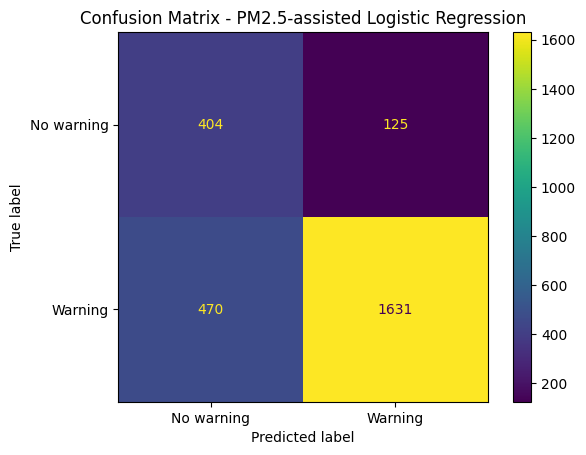

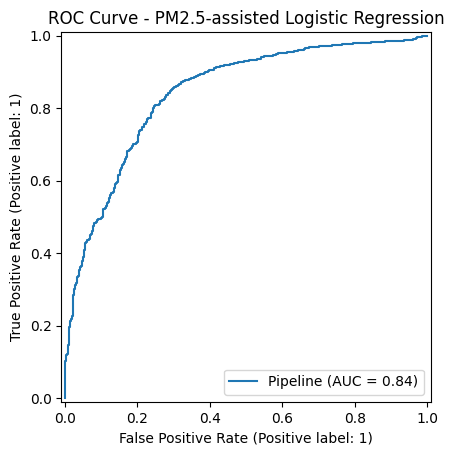

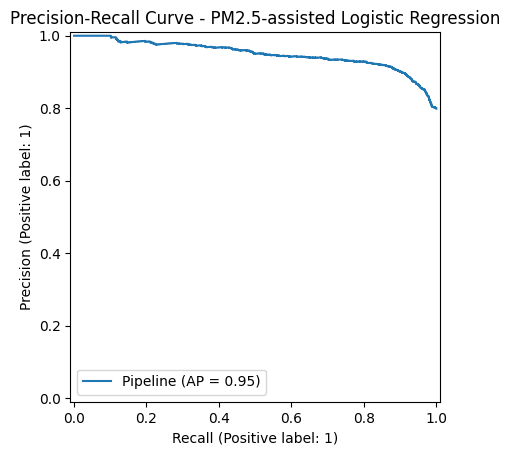

Classification report for PM2.5-assisted Logistic Regression:
              precision    recall  f1-score   support

  No warning       0.46      0.76      0.58       529
     Warning       0.93      0.78      0.85      2101

    accuracy                           0.77      2630
   macro avg       0.70      0.77      0.71      2630
weighted avg       0.83      0.77      0.79      2630



In [105]:
# This model is only used as extra exploration, not as the main required model comparison.

show_confusion_matrix(
    sensor_logistic_model,
    X_test_sensor,
    y_test_sensor,
    "Confusion Matrix - PM2.5-assisted Logistic Regression"
)

plot_roc_and_pr(
    sensor_logistic_model,
    X_test_sensor,
    y_test_sensor,
    "PM2.5-assisted Logistic Regression"
)

print("Classification report for PM2.5-assisted Logistic Regression:")
print(
    classification_report(
        y_test_sensor,
        sensor_logistic_model.predict(X_test_sensor),
        target_names=["No warning", "Warning"],
        zero_division=0
    )
)